In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

drinking_df = pd.read_csv("smoking_driking_dataset_Ver01.csv")
drinking_df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


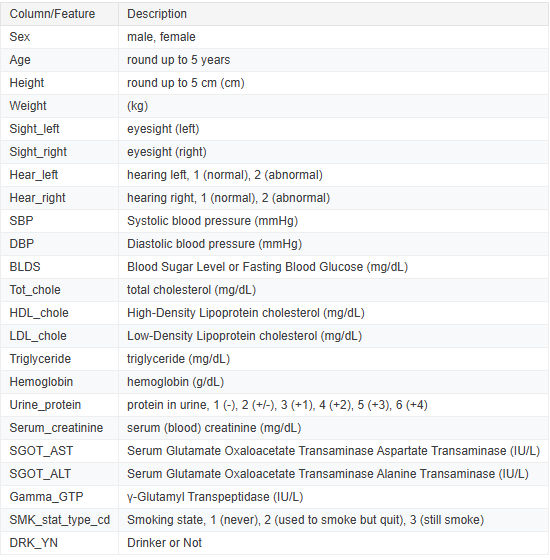

In [4]:
drinking_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.614491,14.181339,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.240625,9.282957,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.284050,12.514241,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.233358,11.850323,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.980834,0.605949,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.978429,0.604774,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.031495,0.174650,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.030476,0.171892,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.432498,14.543148,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.052627,9.889365,32.0,70.0,76.0,82.0,185.0


In [6]:
drinking_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

In [7]:
any_null = drinking_df.isna().sum().sum()
print("Any missing values:", any_null)

Any missing values: 0


In [8]:
num_duplicates = drinking_df.duplicated().sum()
num_total = drinking_df.shape[0]
num_unique = num_total - num_duplicates
print(f"Antall duplikater som ville blitt droppet: {num_duplicates}")
print(f"Prosent beholdt: {(num_unique / num_total) * 100:.10f}%")
drinking_df_unique = drinking_df.drop_duplicates()

Antall duplikater som ville blitt droppet: 26
Prosent beholdt: 99.9973773032%


In [9]:
import pandas as pd
from termcolor import colored

def grab_col_names(dataframe, cat_th=10, car_th=20):

    # Kategoriske kolonner (dtype = object)
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    # Numeriske, men egentlig kategoriske (få unike verdier)
    num_but_cat = [col for col in dataframe.columns 
                   if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]

    # Kategoriske, men egentlig kardinale (mange unike verdier)
    cat_but_car = [col for col in dataframe.columns 
                   if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    # Kombiner ekte kategoriske og numeriske som er kategoriske
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # Numeriske kolonner (ekskluder de som er klassifisert som kategoriske)
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(drinking_df_unique)

print(f"\nNumerical Columns: {num_cols}\n")
print(f"Categorical Columns: {cat_cols}\n")
     


Observations: 991320
Variables: 24
cat_cols: 6
num_cols: 18
cat_but_car: 0
num_but_cat: 4

Numerical Columns: ['age', 'height', 'weight', 'waistline', 'sight_left', 'sight_right', 'SBP', 'DBP', 'BLDS', 'tot_chole', 'HDL_chole', 'LDL_chole', 'triglyceride', 'hemoglobin', 'serum_creatinine', 'SGOT_AST', 'SGOT_ALT', 'gamma_GTP']

Categorical Columns: ['sex', 'DRK_YN', 'hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']



In [10]:
import pandas as pd

# Antar at datasettet ditt heter drinking_df (eller drinking_df_unique)
df = drinking_df_unique.copy()

# Velg kategoriske kolonner (dtype = object eller category)
cat_cols = df.select_dtypes(include=["object", "category"]).columns

# Skriv ut antall unike og hvilke verdier for hver kolonne
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"Kolonne: {col}")
    print(f"Antall unike verdier: {df[col].nunique()}")
    print(f"Unike verdier: {unique_vals}")
    print("-" * 50)


Kolonne: sex
Antall unike verdier: 2
Unike verdier: ['Male' 'Female']
--------------------------------------------------
Kolonne: DRK_YN
Antall unike verdier: 2
Unike verdier: ['Y' 'N']
--------------------------------------------------


In [15]:
drinking_df_unique

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [ ]:
vi vil ikke fjerne outliers ifra alle eksmeplvis protien in urin her må vi skrive om hva data betyr i teskten 

In [12]:
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ['sex', 'hear_left', 'hear_right', 'urine_protein', 'SMK_stat_type_cd']

# Funksjon for å beregne sannsynlighet for å drikke (DRK_YN = Y)
def drinking_prob_by_category(data, cat_cols, target="DRK_YN", positive="Y"):
    results = {}
    for col in cat_cols:
        if col == target:  # hopper over selve target
            continue
        # Krysstabell med sannsynlighet
        ct = pd.crosstab(data[col], data[target], normalize="index") * 100
        if positive in ct.columns:
            results[col] = ct[positive]
        else:
            results[col] = pd.Series(0, index=ct.index)  # fallback hvis Y ikke finnes
    return results

results = drinking_prob_by_category(df, cat_cols)

# Print resultater
for col, probs in results.items():
    print(f"\nSannsynlighet for å drikke (DRK_YN='Y') gitt {col}:")
    print(probs.round(2).astype(str) + " %")



Sannsynlighet for å drikke (DRK_YN='Y') gitt sex:
sex
Female    30.36 %
Male      67.31 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt hear_left:
hear_left
1.0    50.51 %
2.0    33.81 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt hear_right:
hear_right
1.0     50.5 %
2.0    33.56 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt urine_protein:
urine_protein
1.0    49.92 %
2.0    53.97 %
3.0    49.02 %
4.0    46.06 %
5.0    42.08 %
6.0     41.8 %
Name: Y, dtype: object

Sannsynlighet for å drikke (DRK_YN='Y') gitt SMK_stat_type_cd:
SMK_stat_type_cd
1.0    35.43 %
2.0    68.86 %
3.0    75.52 %
Name: Y, dtype: object


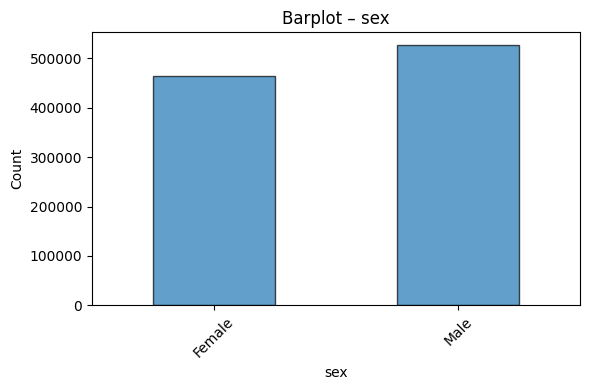

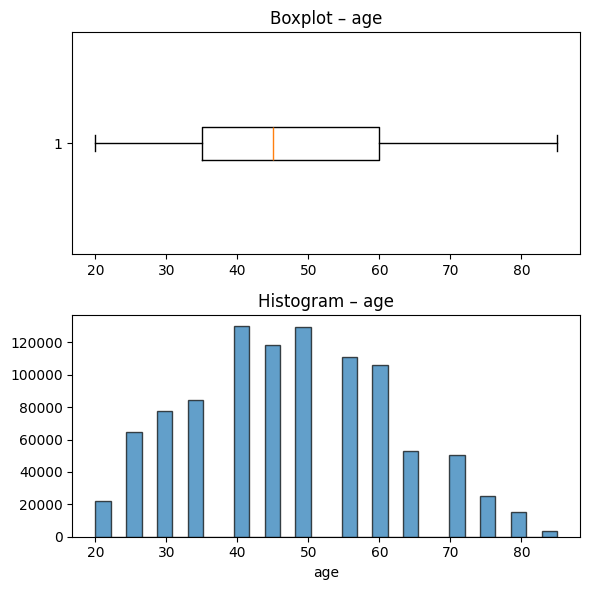

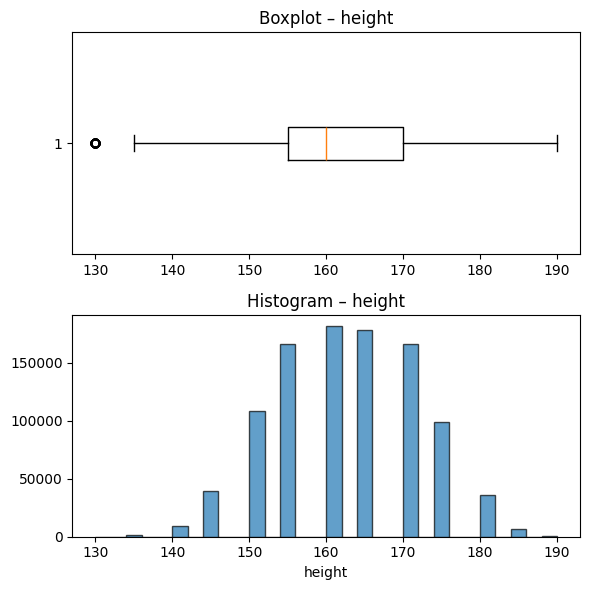

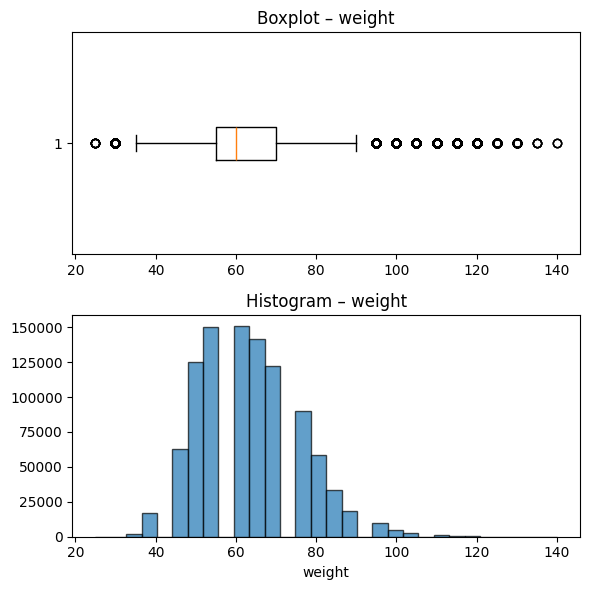

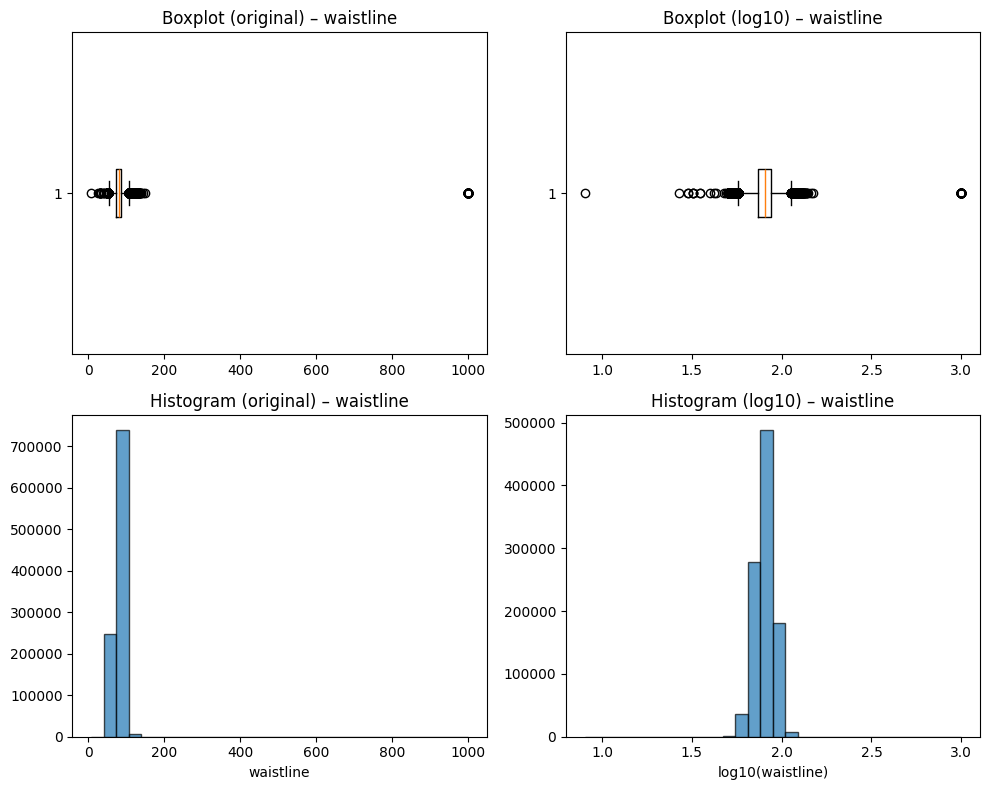

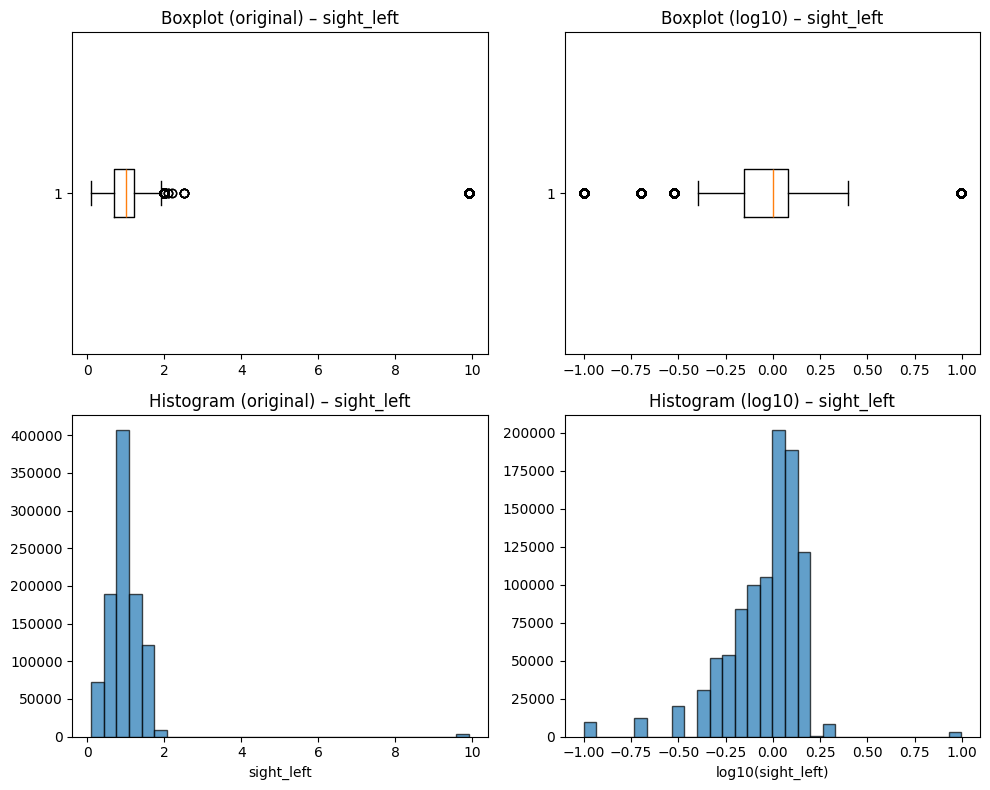

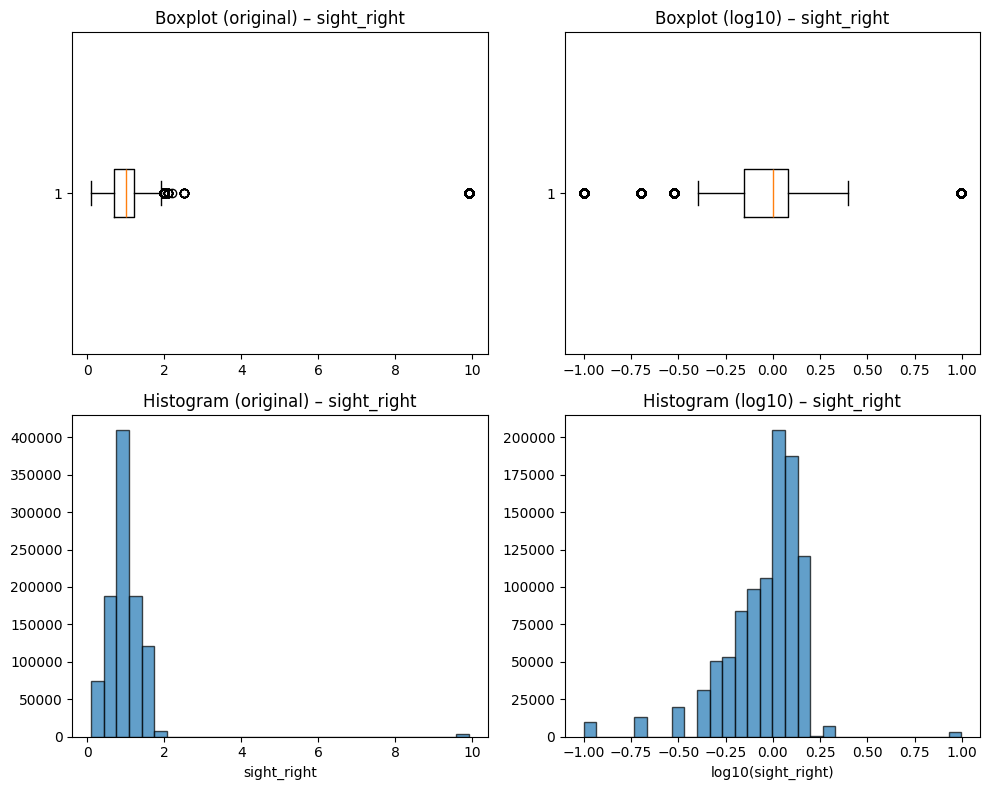

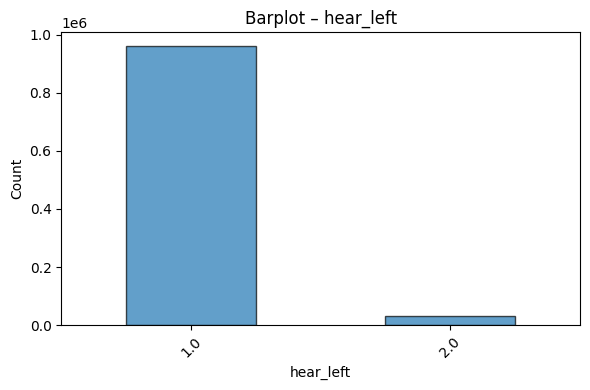

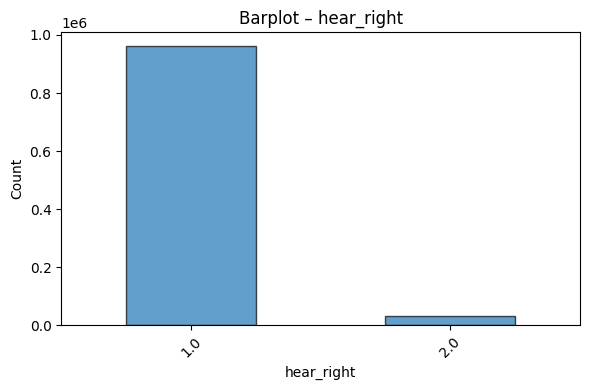

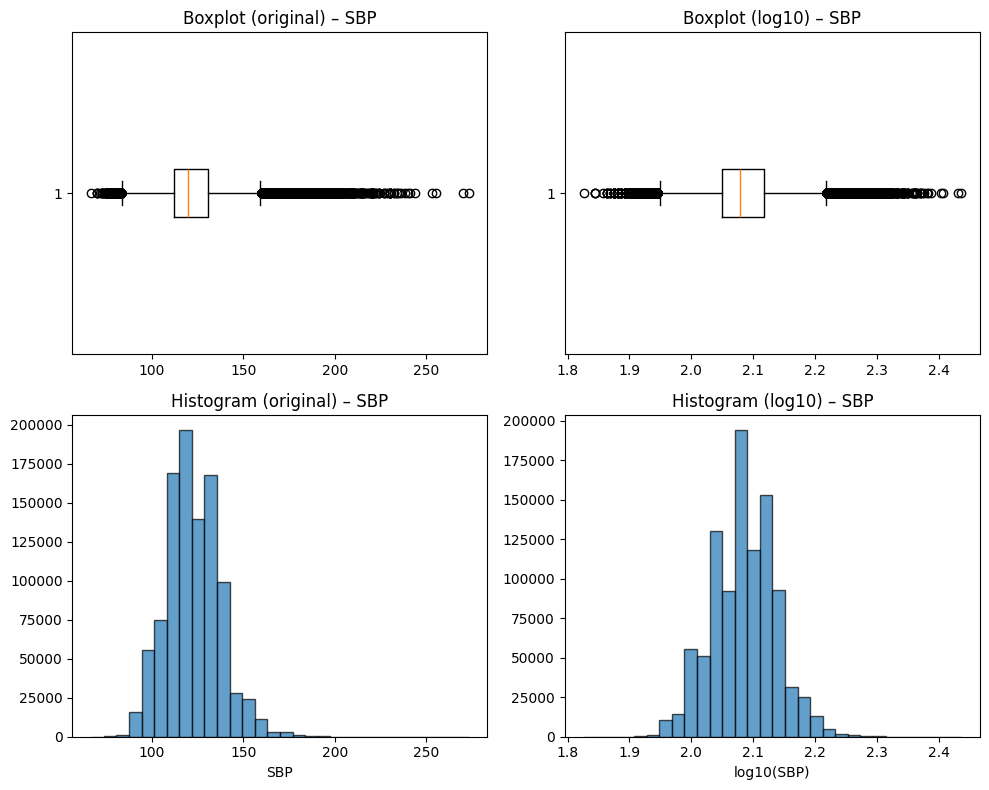

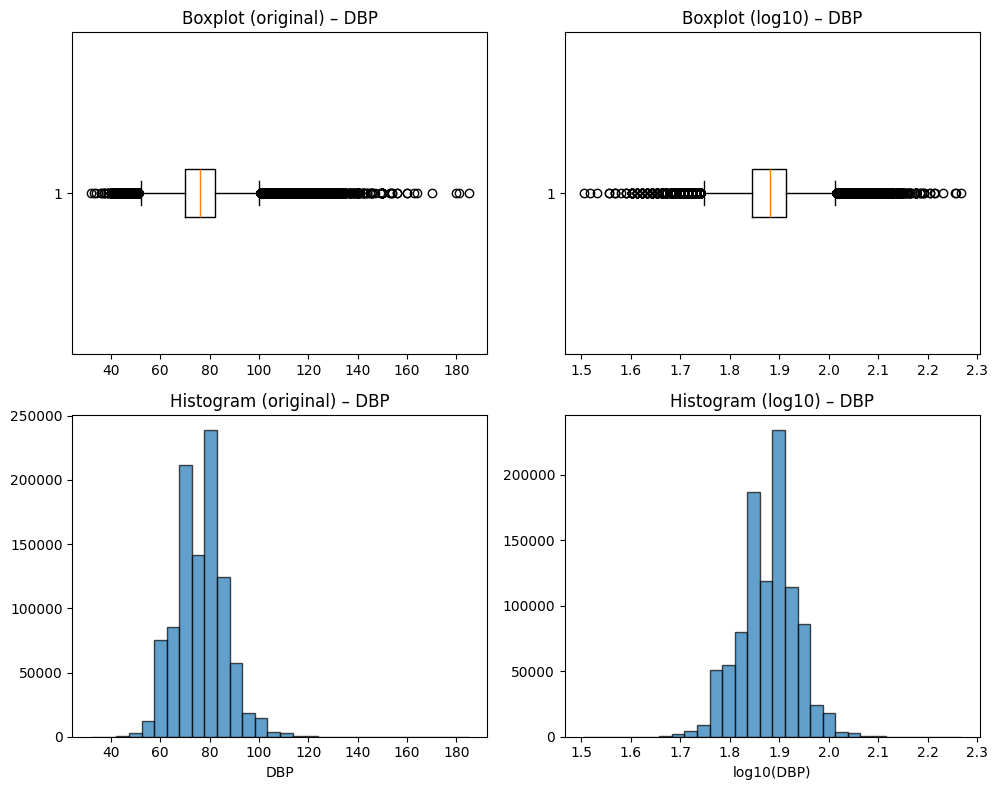

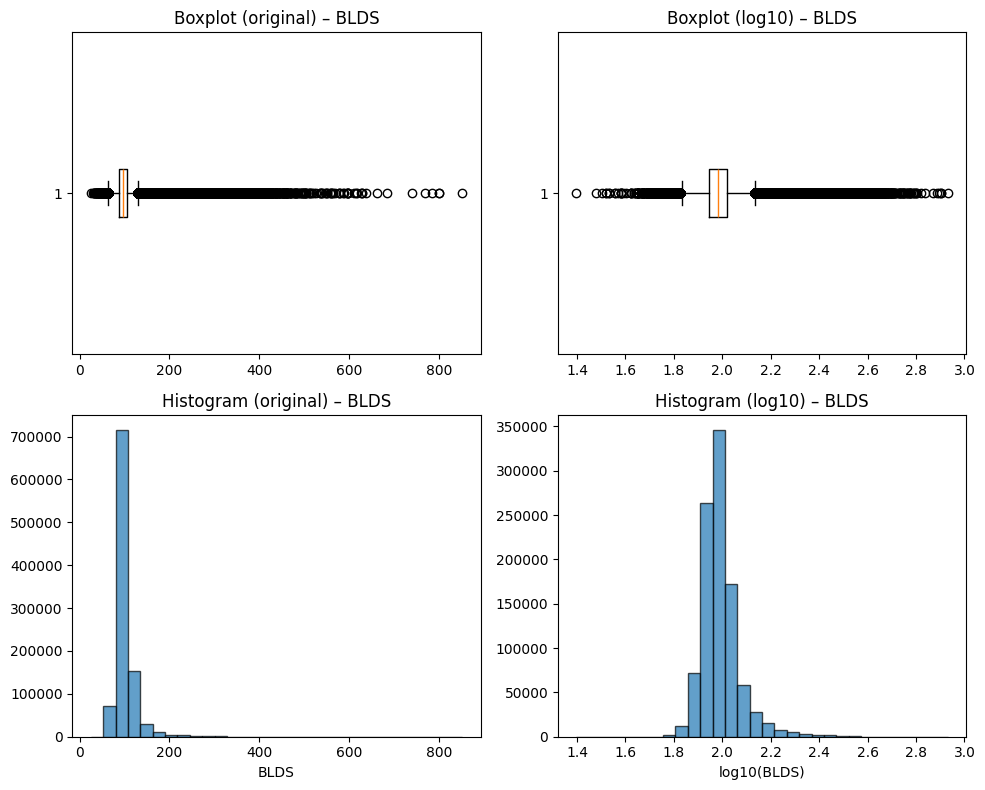

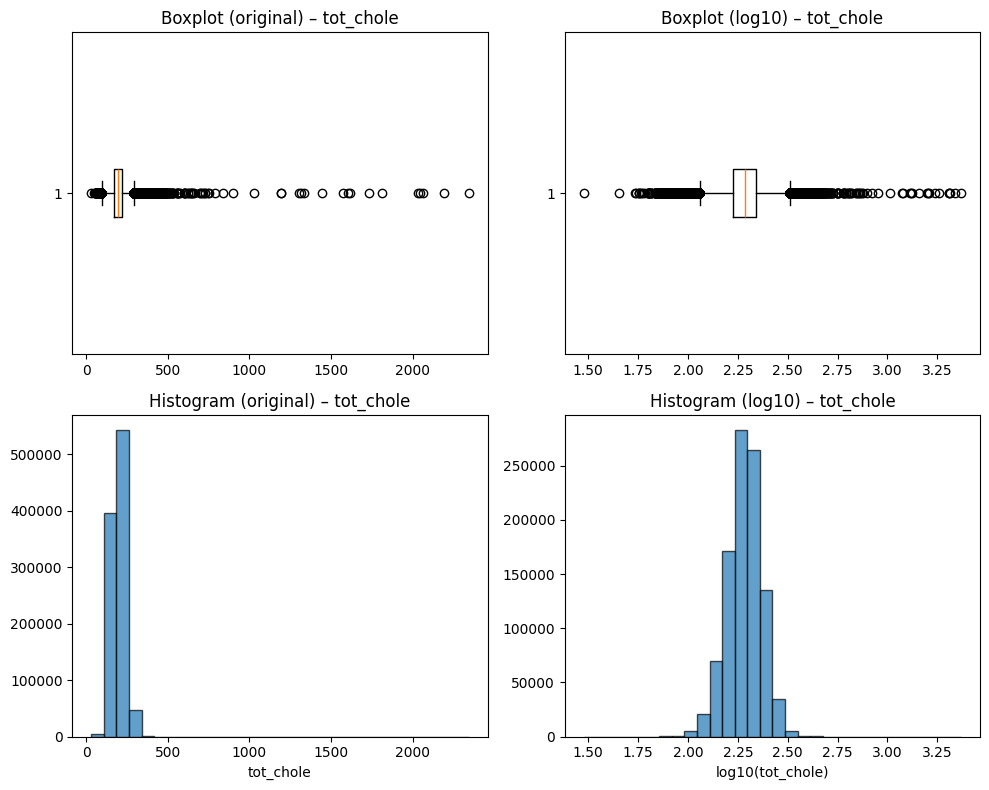

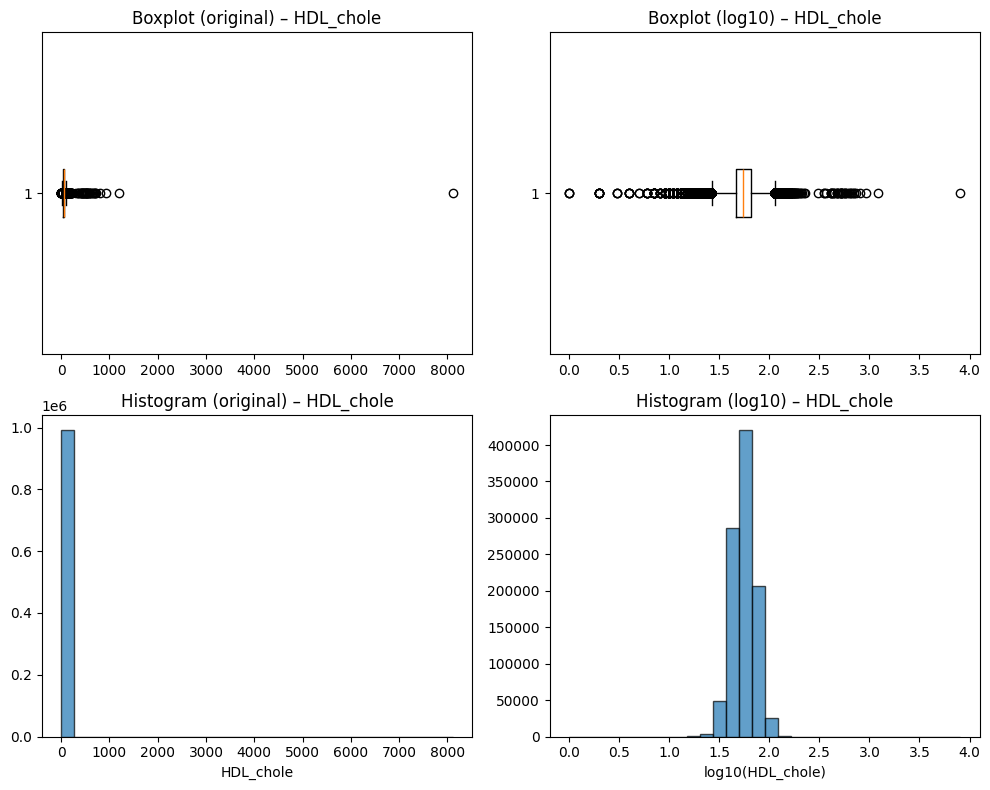

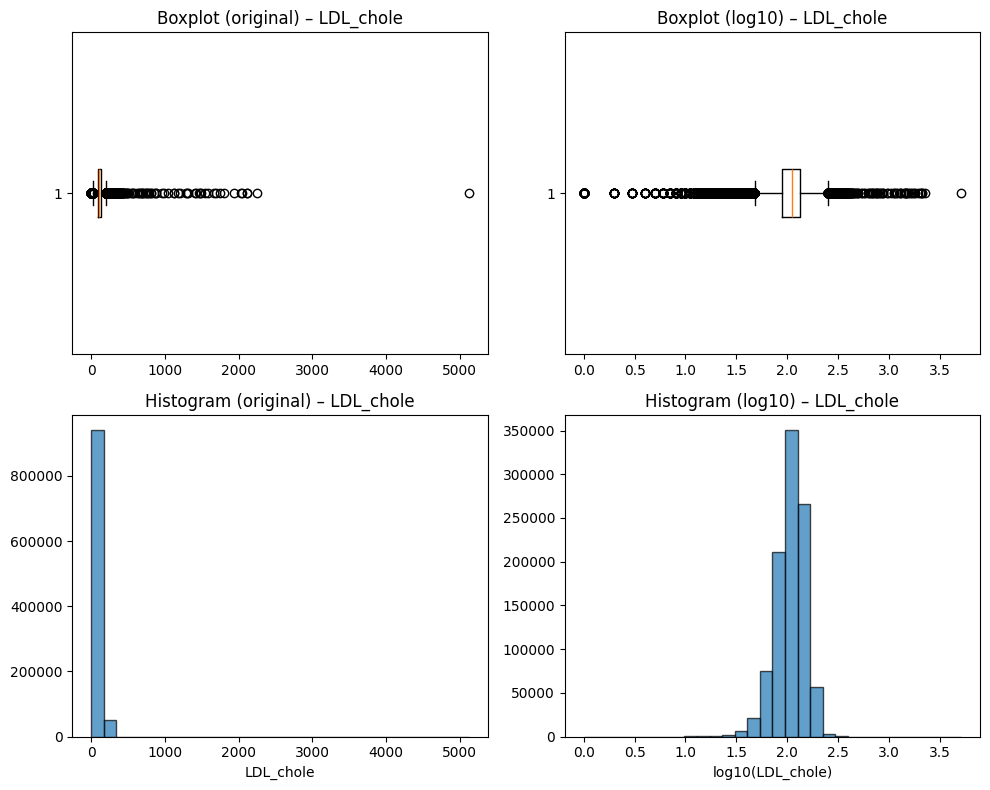

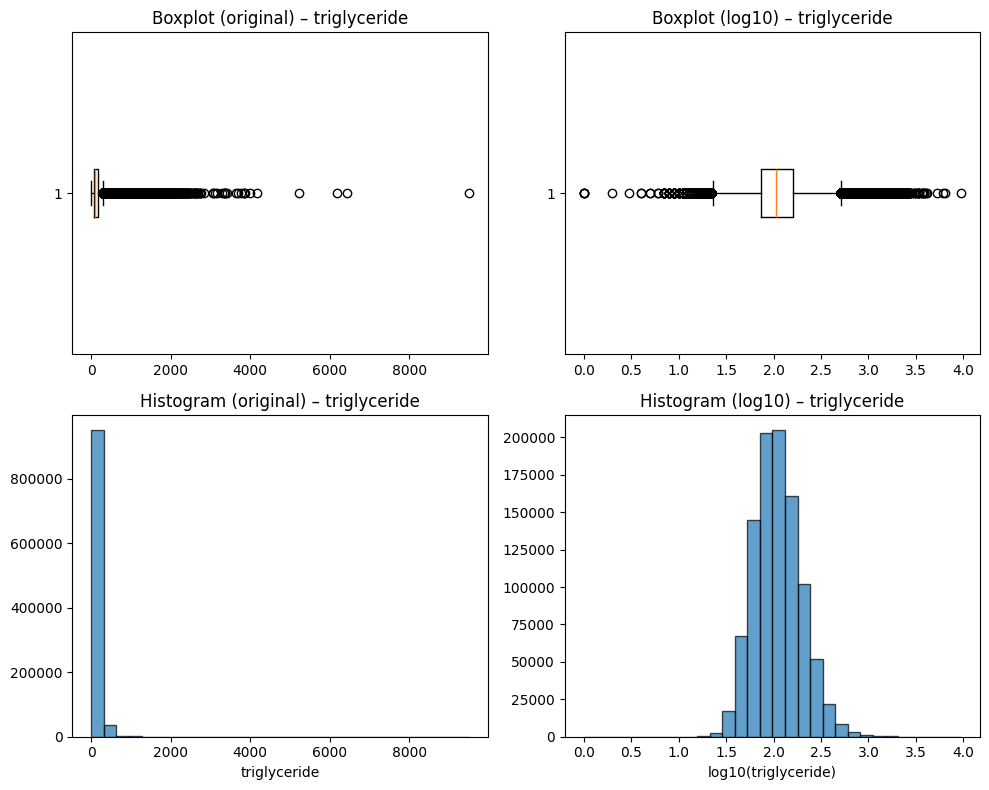

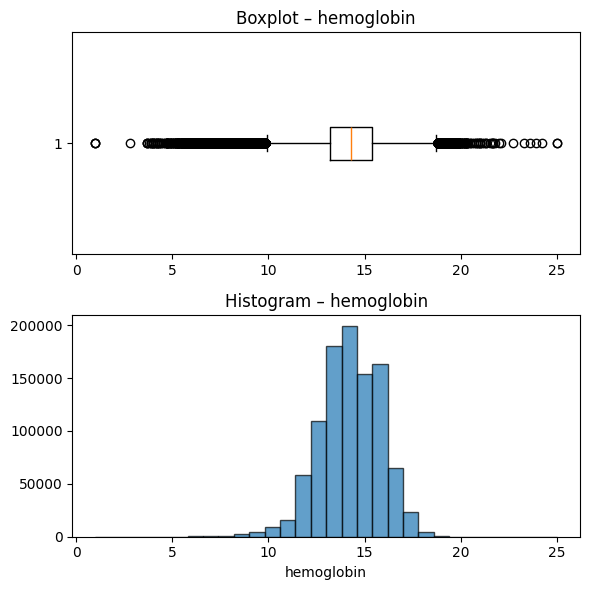

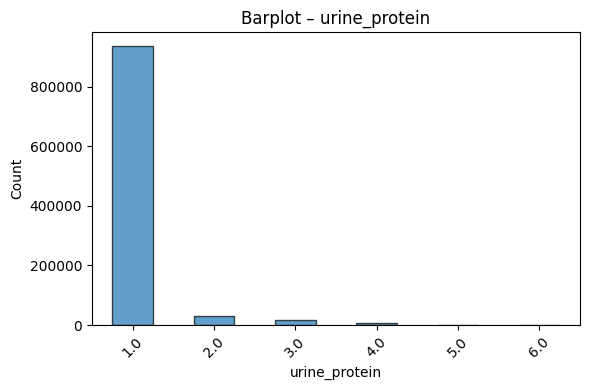

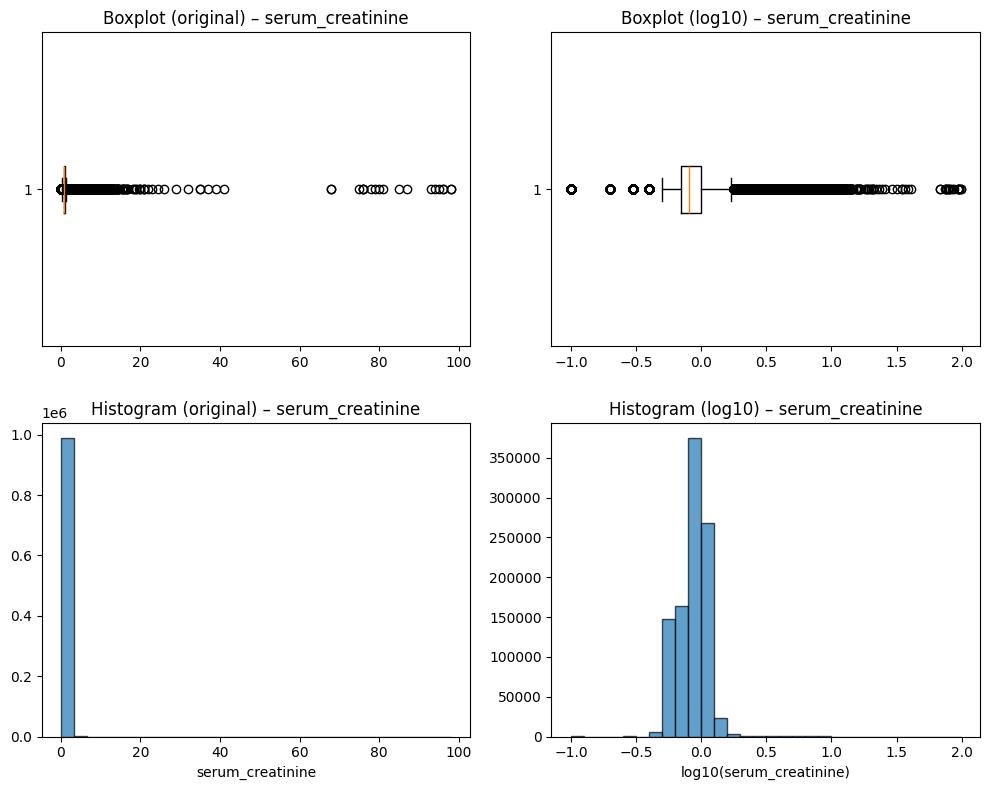

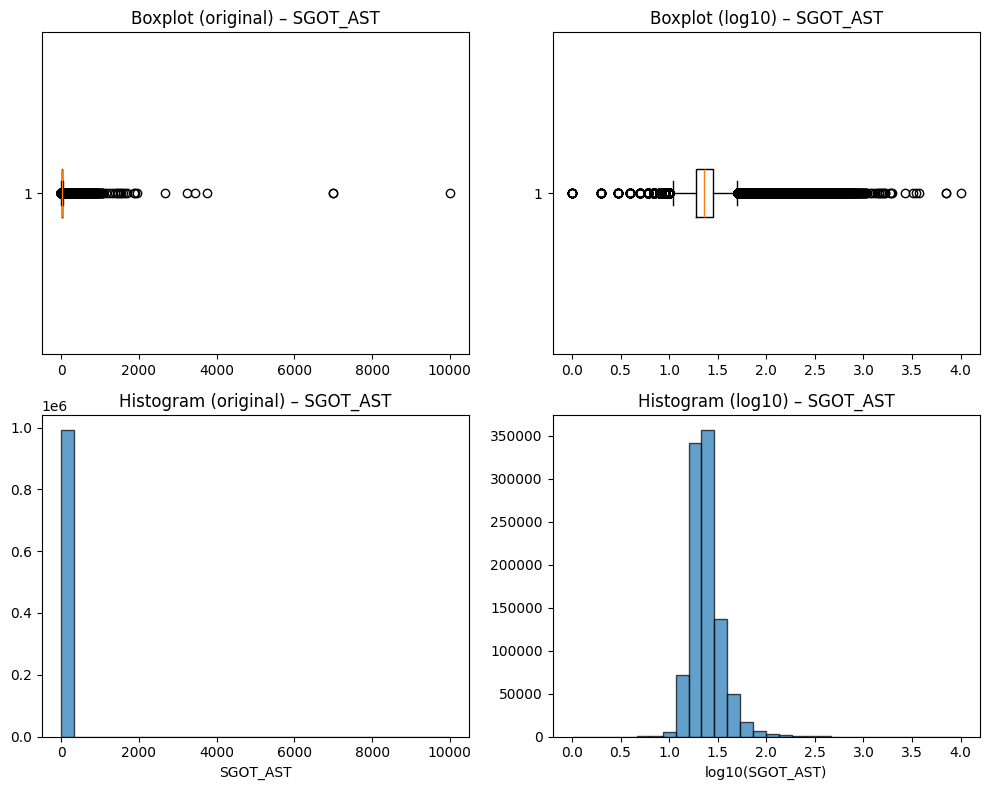

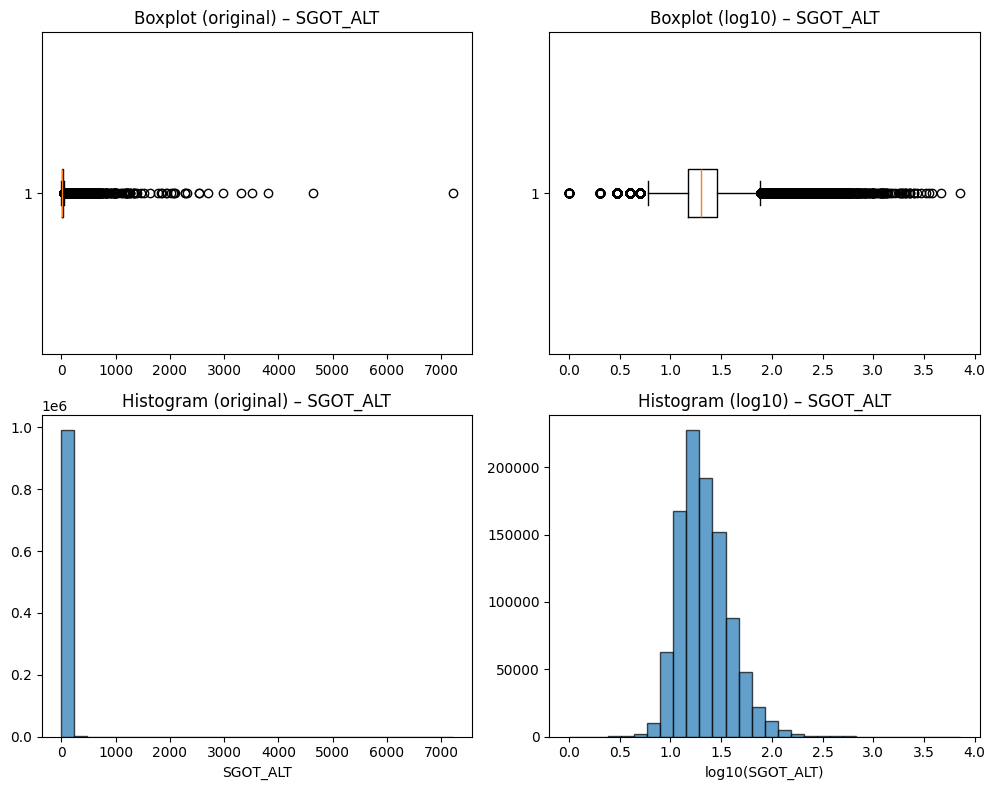

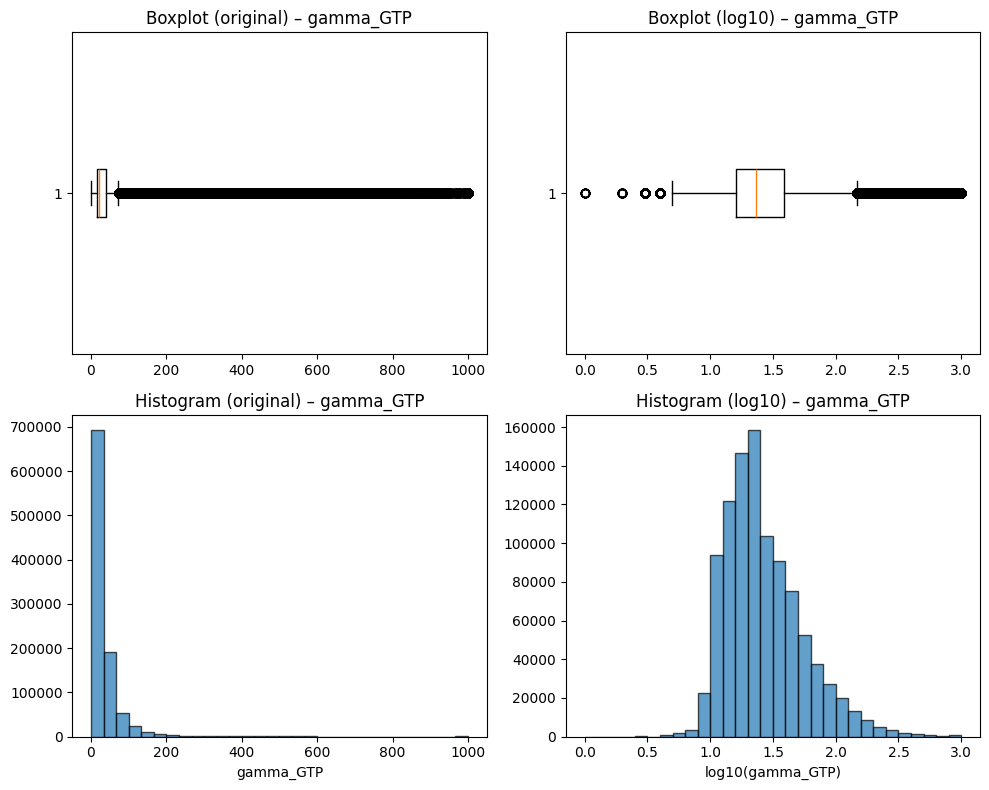

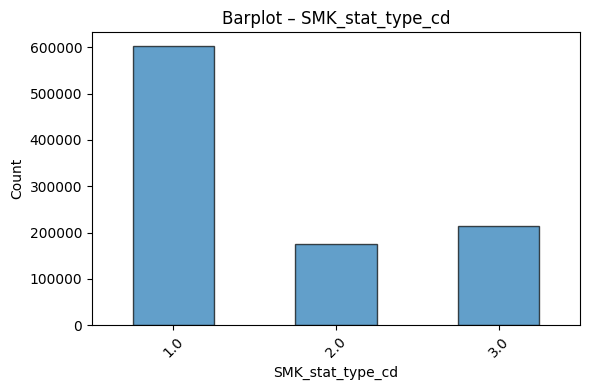

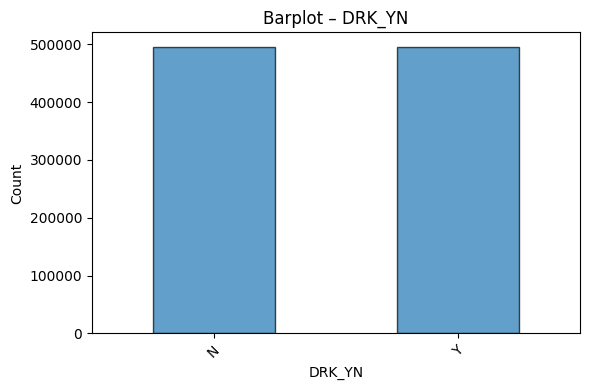

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

# Kopi av originalen – behold alt
df_log = df.copy()

def plot_with_optional_log(df, col, bins=30, allow_log=True):
    global df_log   
    
    data = df[col].dropna()
    if data.empty:
        return
    
    if col in cat_cols:
        counts = data.value_counts().sort_index()
        plt.figure(figsize=(6,4))
        counts.plot(kind="bar", edgecolor="black", alpha=0.7)
        plt.title(f"Barplot – {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        return
    
    # --- Hvis numerisk: log-transformer hvis lov ---
    log_data = None
    if allow_log and (data > 0).all():
        log_data = np.log10(data)
        df_log[col] = log_data   # overskriv i df_log
    
    if log_data is not None:
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        # Original
        axes[0,0].boxplot(data, vert=False, showfliers=True)
        axes[0,0].set_title(f"Boxplot (original) – {col}")
        axes[1,0].hist(data, bins=bins, edgecolor="black", alpha=0.7)
        axes[1,0].set_title(f"Histogram (original) – {col}")
        axes[1,0].set_xlabel(col)
        # Log
        axes[0,1].boxplot(log_data, vert=False, showfliers=True)
        axes[0,1].set_title(f"Boxplot (log10) – {col}")
        axes[1,1].hist(log_data, bins=bins, edgecolor="black", alpha=0.7)
        axes[1,1].set_title(f"Histogram (log10) – {col}")
        axes[1,1].set_xlabel(f"log10({col})")
    else:
        fig, axes = plt.subplots(2, 1, figsize=(6, 6))
        axes[0].boxplot(data, vert=False, showfliers=True)
        axes[0].set_title(f"Boxplot – {col}")
        axes[1].hist(data, bins=bins, edgecolor="black", alpha=0.7)
        axes[1].set_title(f"Histogram – {col}")
        axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

# Kjør plotting for alle kolonner
for col in df.columns:
    allow_log = (col not in no_log and col not in cat_cols)
    plot_with_optional_log(df, col, allow_log=allow_log)




In [32]:
df_log

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,1.954243,0.000000,0.000000,1.0,1.0,2.079181,...,2.100371,1.963788,17.1,1.0,0.000000,1.322219,1.544068,1.602060,1.0,Y
1,Male,30,180,80,1.949390,-0.045757,0.079181,1.0,1.0,2.113943,...,2.170262,2.082785,15.8,1.0,-0.045757,1.301030,1.556303,1.431364,3.0,N
2,Male,40,165,75,1.959041,0.079181,0.176091,1.0,1.0,2.079181,...,1.869232,2.017033,15.8,1.0,-0.045757,1.672098,1.505150,1.832509,1.0,N
3,Male,50,175,80,1.959041,0.176091,0.079181,1.0,1.0,2.161368,...,2.017033,2.025306,17.6,1.0,0.041393,1.462398,1.531479,1.255273,1.0,N
4,Male,50,165,60,1.903090,0.000000,0.079181,1.0,1.0,2.139879,...,2.068186,2.017033,13.8,1.0,-0.096910,1.278754,1.079181,1.397940,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,1.964260,0.176091,0.176091,1.0,1.0,2.056905,...,2.096910,2.120574,15.0,1.0,0.000000,1.414973,1.556303,1.431364,1.0,N
991342,Male,35,170,75,1.934498,0.000000,0.176091,1.0,1.0,2.075547,...,1.924279,1.653213,15.8,1.0,0.041393,1.146128,1.230449,1.176091,1.0,N
991343,Female,40,155,50,1.832509,0.000000,-0.154902,1.0,1.0,2.041393,...,1.886491,2.195900,14.3,1.0,-0.096910,1.477121,1.431364,1.230449,3.0,Y
991344,Male,25,175,60,1.857332,0.176091,0.000000,1.0,1.0,2.075547,...,1.863323,1.724276,14.5,1.0,-0.096910,1.322219,1.146128,1.230449,1.0,N


Antall rader før: 991320, etter fjerning av outliers: 945400


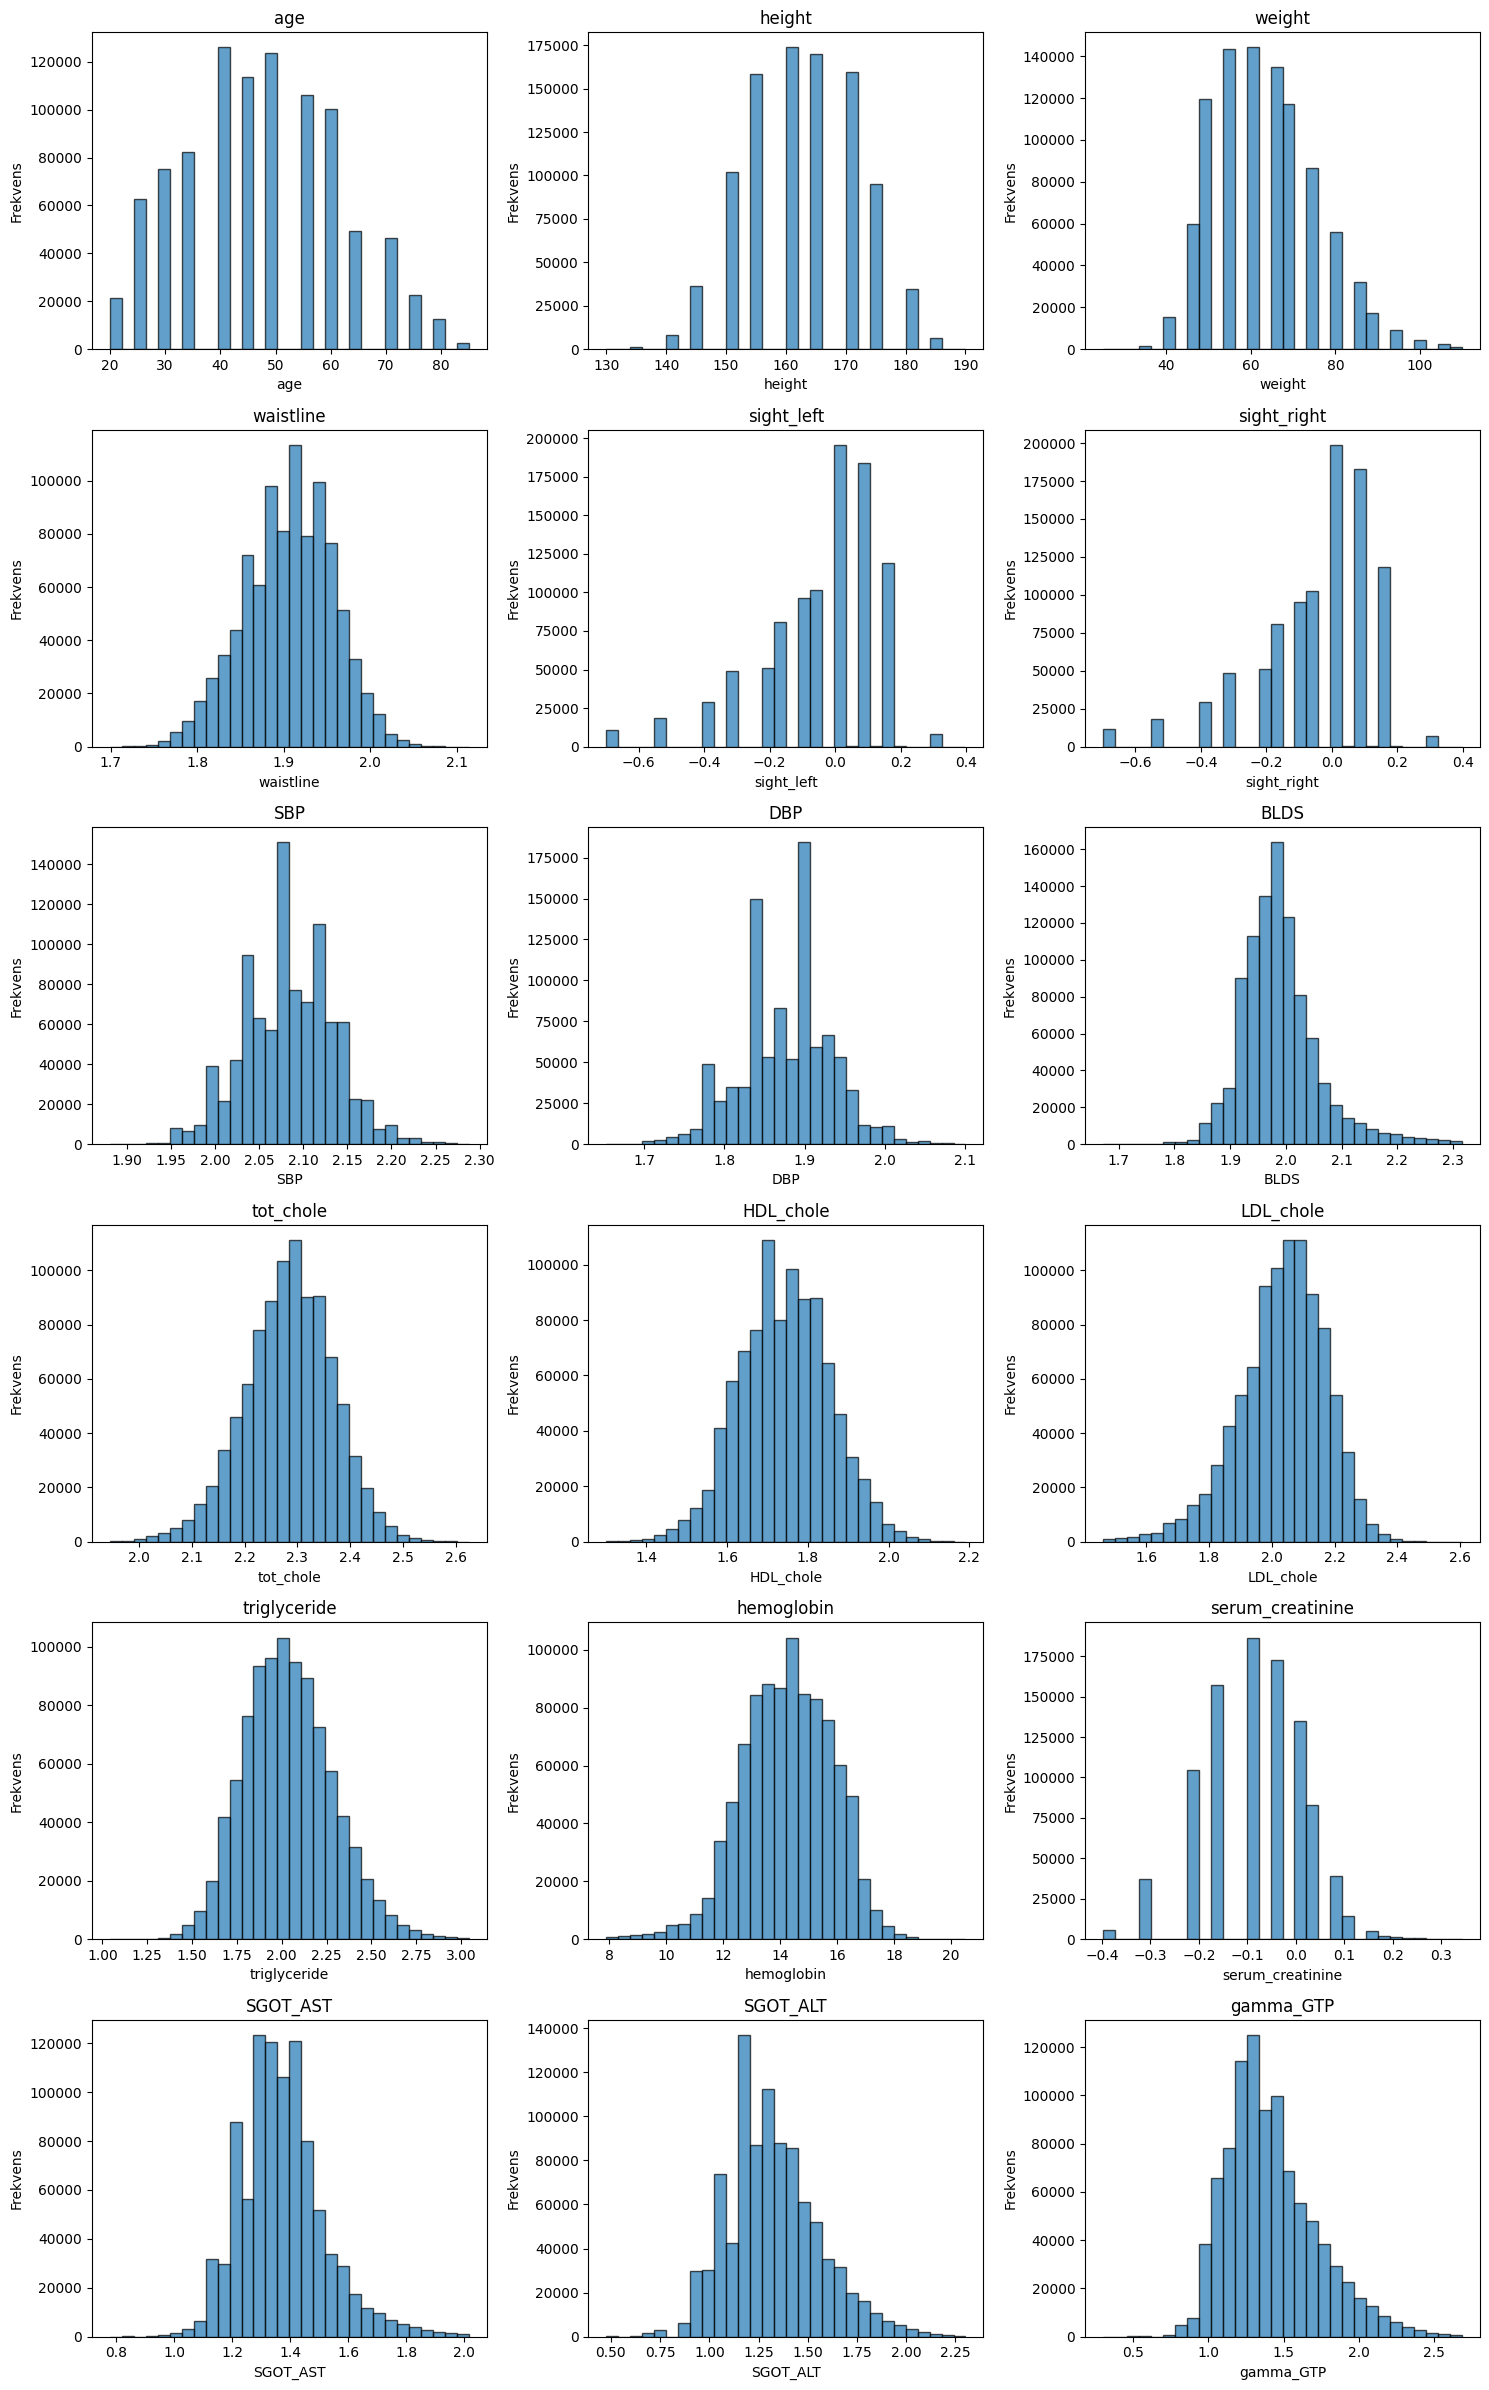

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Bruk df_log (med log-transformerte kolonner)
df = df_log.copy()

# Kolonnene vi faktisk vil sjekke
columns_to_check = [
    "age",
    "height",
    "weight",
    "waistline",
    "sight_left",
    "sight_right",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "hemoglobin",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP",
]

z_scores = df[columns_to_check].apply(zscore)
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_clean = df[mask].copy()
print(f"Antall rader før: {len(df)}, etter fjerning av outliers: {len(df_clean)}")
n_cols = 3
n_rows = int(np.ceil(len(columns_to_check) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns_to_check):
    axes[i].hist(df_clean[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekvens")

# Fjern overflødige subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [22]:
df_clean

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,1.954243,0.000000,0.000000,1.0,1.0,2.079181,...,2.100371,1.963788,17.1,1.0,0.000000,1.322219,1.544068,1.602060,1.0,Y
1,Male,30,180,80,1.949390,-0.045757,0.079181,1.0,1.0,2.113943,...,2.170262,2.082785,15.8,1.0,-0.045757,1.301030,1.556303,1.431364,3.0,N
2,Male,40,165,75,1.959041,0.079181,0.176091,1.0,1.0,2.079181,...,1.869232,2.017033,15.8,1.0,-0.045757,1.672098,1.505150,1.832509,1.0,N
3,Male,50,175,80,1.959041,0.176091,0.079181,1.0,1.0,2.161368,...,2.017033,2.025306,17.6,1.0,0.041393,1.462398,1.531479,1.255273,1.0,N
4,Male,50,165,60,1.903090,0.000000,0.079181,1.0,1.0,2.139879,...,2.068186,2.017033,13.8,1.0,-0.096910,1.278754,1.079181,1.397940,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,1.964260,0.176091,0.176091,1.0,1.0,2.056905,...,2.096910,2.120574,15.0,1.0,0.000000,1.414973,1.556303,1.431364,1.0,N
991342,Male,35,170,75,1.934498,0.000000,0.176091,1.0,1.0,2.075547,...,1.924279,1.653213,15.8,1.0,0.041393,1.146128,1.230449,1.176091,1.0,N
991343,Female,40,155,50,1.832509,0.000000,-0.154902,1.0,1.0,2.041393,...,1.886491,2.195900,14.3,1.0,-0.096910,1.477121,1.431364,1.230449,3.0,Y
991344,Male,25,175,60,1.857332,0.176091,0.000000,1.0,1.0,2.075547,...,1.863323,1.724276,14.5,1.0,-0.096910,1.322219,1.146128,1.230449,1.0,N


In [35]:

df_clean["sex"] = df_clean["sex"].map({"Male": 0, "Female": 1})
df_clean["DRK_YN"] = df_clean["DRK_YN"].map({"N": 0, "Y": 1})

df_clean = df_clean.round(1)

df_clean.to_csv("drinking_df_encoded.csv", index=False)

print("done")


done


In [36]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("drinking_df_encoded.csv")

num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
num_cols = [c for c in num_cols if c != "DRK_YN"]

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.to_csv("drinking_df_encoded.csv", index=False)

print("done")


done


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("drinking_df_encoded.csv")

X = df.drop(columns=["DRK_YN"])   
y = df["DRK_YN"]                  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 756320
Test size: 189080


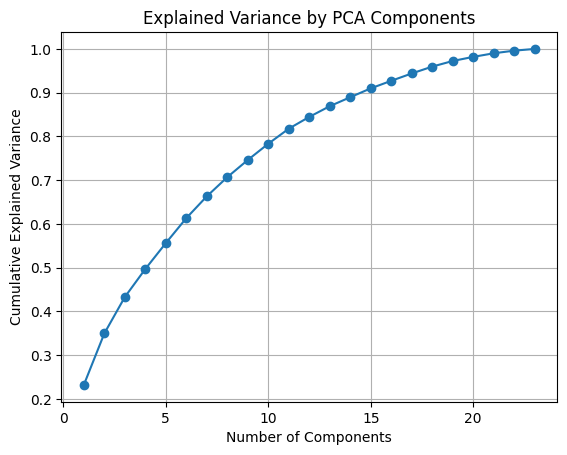

Antall komponenter for å forklare 80% av variansen: 11


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X = numeriske features uten target
X = df_clean.drop(columns=["DRK_YN"])
X_scaled = StandardScaler().fit_transform(X)

# PCA på alle features
pca = PCA()
pca.fit(X_scaled)

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

# Hvor mange trengs for 80%?
n_components_80 = np.argmax(cum_var >= 0.8) + 1
print(f"Antall komponenter for å forklare 80% av variansen: {n_components_80}")


In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X = numeriske features uten target
X = df_clean.drop(columns=["DRK_YN"])
X_scaled = StandardScaler().fit_transform(X)

# Behold 11 komponenter
pca = PCA(n_components=11)
X_pca = pca.fit_transform(X_scaled)

# Lag nytt DataFrame
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(11)])
print(pca_df.head())


        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.482451 -0.634344  0.299190  0.123768 -0.656999 -0.160586  0.029712   
1 -3.002394 -1.616249  1.299587  0.901525 -0.724579 -0.488462  0.376479   
2 -2.621875 -0.713376 -1.812899 -1.266098  1.881377  0.901396 -0.765546   
3 -2.863746 -0.605448  0.273772 -0.489527 -0.928507  1.469764  1.305942   
4  0.275277 -0.494290  0.468565  0.113883 -1.036956  0.415772  0.142637   

        PC8       PC9      PC10      PC11  
0 -0.364175 -1.020115  0.823535  0.322997  
1 -0.146037  0.049133 -0.006659 -0.574398  
2 -0.414802 -0.914388  0.466795  1.346132  
3 -0.290288 -0.906498  1.458651  1.088488  
4 -0.010484  0.389703  0.466294  0.395822  
